Run a simulation and sample genomes from the transmission network.

Sample at say 1%, 5%, and 10% of the transmissions (to begin with) and reconstruct the phylogeny.

In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt

import covasim as cv
from Bio import SeqIO

from covasim.jhk_covasim4wastewater.intervention_search.simulation.runner import run_evo_simulation
from covasim.jhk_covasim4wastewater.intervention_search.analysis.mutation_tree import build_mutation_tree, build_infection_seq_tree, extract_sequenced_subtree, add_internal_leaves, mutation_tree_to_newick, export_fasta_from_G, set_all_branch_lengths_to_one
from covasim.jhk_covasim4wastewater.intervention_search.plotting.plot_mutation_tree import plot_mutation_tree, plot_erase_mutation_tree, plot_phylo_tree

# from covasim.transmission_tree import TransmissionTree
# from covasim.metrics import Metrics
from covasim.inference import Inference

In [84]:
REF_FASTA     = 'sars-2-data/NC_045512_Hu-1.fasta'
FITNESS_CSV   = '../../data/nt_fitness.csv'
ARTIC_PRIMERS = 'sars-2-data/ARTIC_V4-1.bed'
FIG_DIR = "/home/yutianc/covasim4wastewater/docs/tutorials/results"

ay4_fasta   = 'sars-2-data/variants/AY.4_consensus.fasta'
ba2_fasta   = 'sars-2-data/variants/BA.2.9_consensus.fasta'
xbb15_fasta = 'sars-2-data/variants/XBB.1.5.18_consensus.fasta'


In [141]:
ay4 = cv.variant(
    variant        = {},
    label          = 'AY.4',
    days           = 30,
    n_imports      = 60,
    founding_fasta = ay4_fasta,
)
ba2 = cv.variant(
    variant        = {},
    label          = 'BA.2',
    days           = 70,
    n_imports      = 60,
    founding_fasta = ba2_fasta,
)
xbb15 = cv.variant(
    variant        = {},
    label          = 'XBB.1.5',
    days           = 110,
    n_imports      = 60,
    founding_fasta = xbb15_fasta,
)

sample_days = list(range(10, 121, 10))
# Routine clinical: 50 symptomatic agents per day, every 10 days.
cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 50,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

In [142]:
evo_pars = dict(
    enable            = True,
    reference         = REF_FASTA,
    mol_clock_rate    = 1e-4, # ~1 substitution/genome/month at 30 000 nt
    sub_model         = 'JC', # decides which mutations happen
    fitness_model = "bloom_nt", # controls transmission rate
    fitness_data_path = FITNESS_CSV,
    store_infection_log=True,
)
sim_pars = dict(
    pop_size=100,
    pop_type='hybrid',
    pop_infected=1,
    start_day='2021-01-01', 
    n_days=121,
    rand_seed=1,
    verbose=0,    
    variants=[xbb15],
    analyzers=[cs_routine],    
)
policy_pars = dict(
    p_test=0.3,
    p_seq=0.5,
    detection_threshold=3,
    delay_pmf=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03],
    quiet_period=0,
)
sim, obs, interv, _, results = run_evo_simulation(sim_pars, evo_pars, policy_pars)

cs_routine = sim.get_analyzer('CS_routine')

/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 20: requested 50 samples but only 1 agents are available in pool='symptomatic'. Returning all 1 agents.
  warnings.warn(


Policy B mutation tree: nodes=113, edges=112


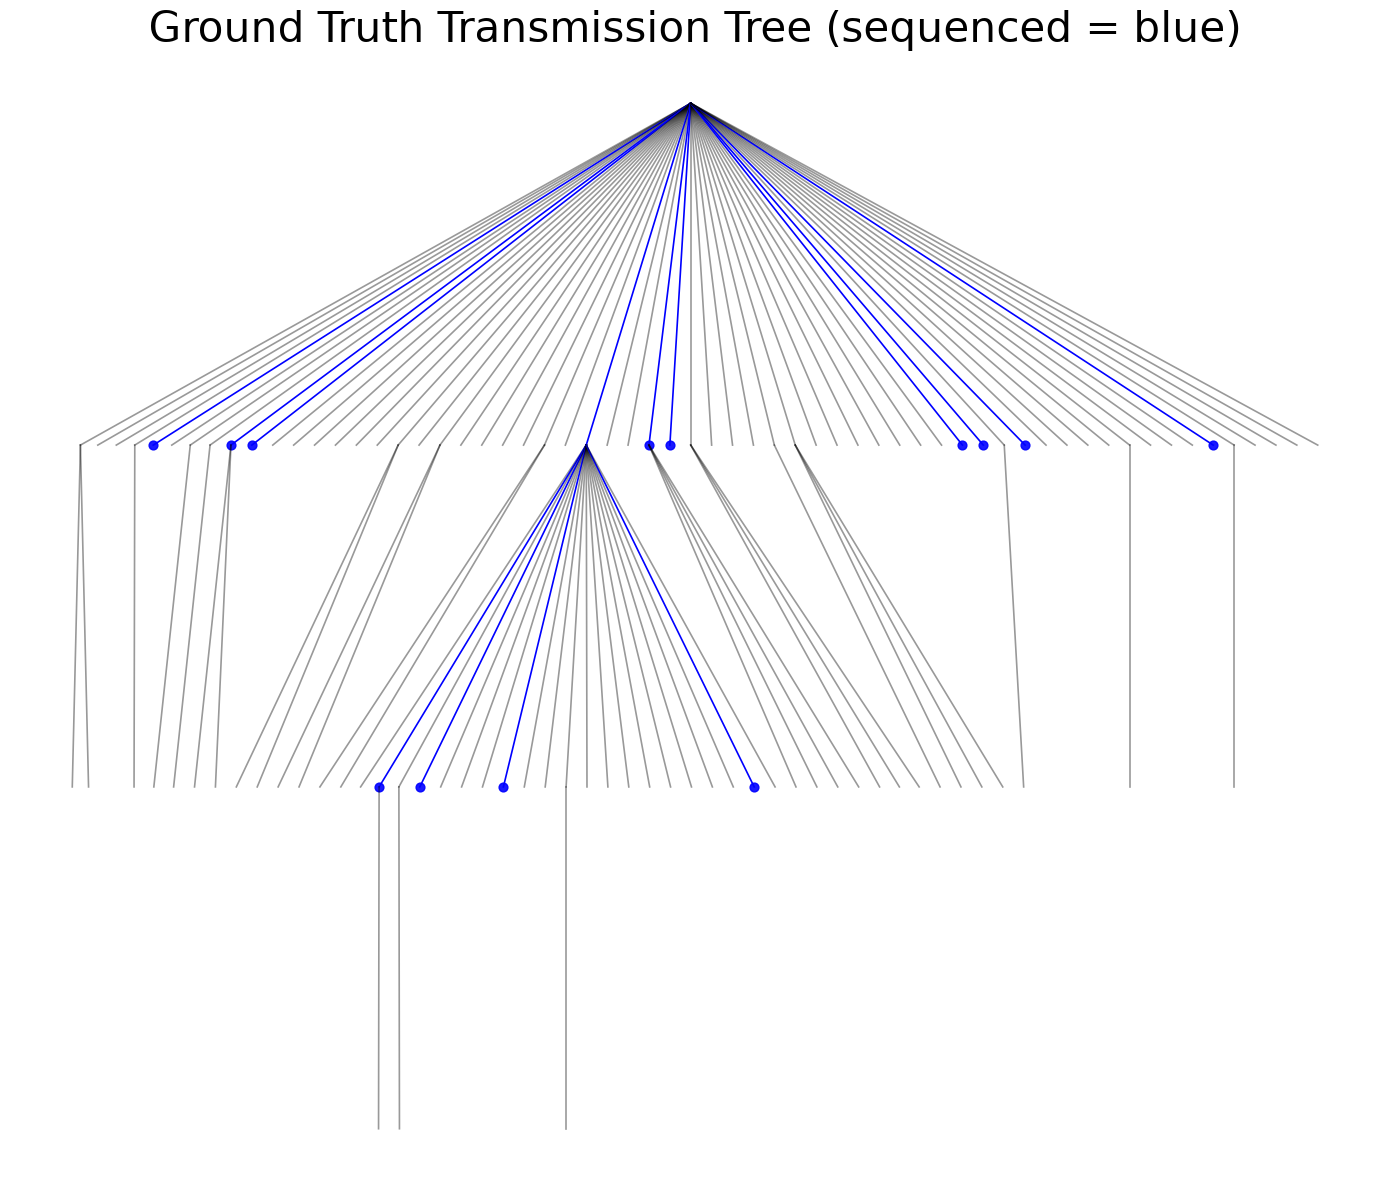

In [143]:
sequenced_agents = set()
for day_list in obs.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_erase_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

Policy B mutation tree: nodes=3, edges=2


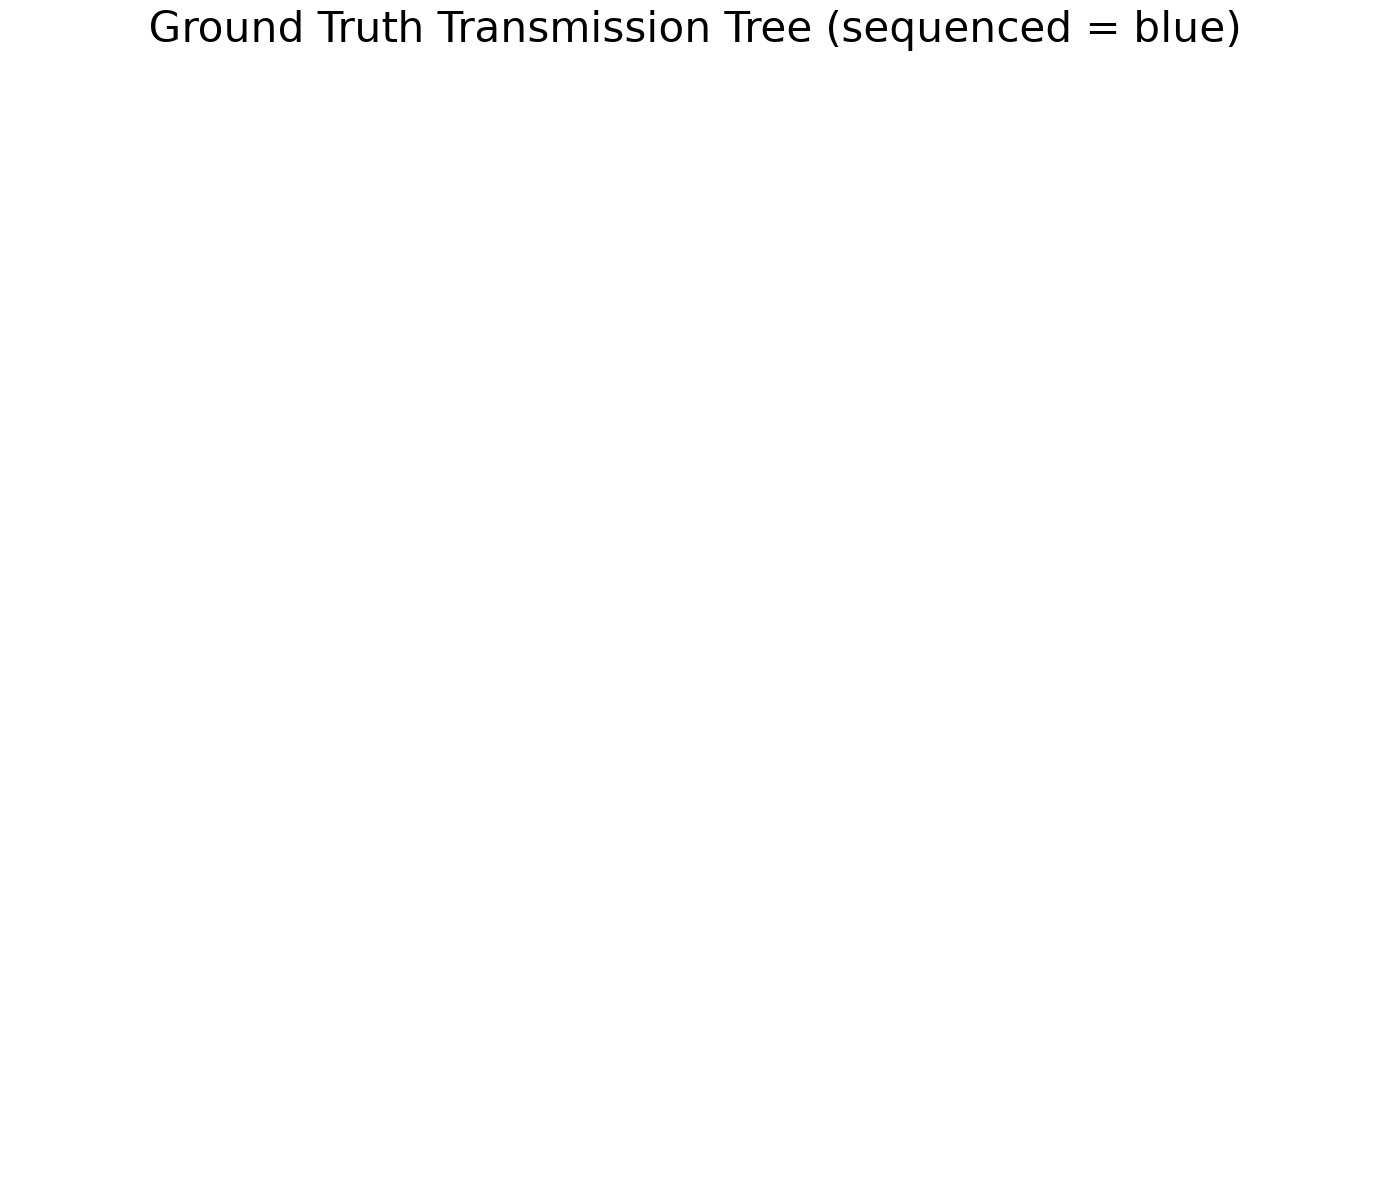

In [137]:
G_infect, mutation_nodes, node_events = build_infection_seq_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G_infect.nodes)}, edges={len(G_infect.edges)}")

plot_erase_mutation_tree(
    G_infect,
    savepath="/home/yutianc/covasim4wastewater/docs/tutorials/results/mutation_tree_policy_seq.png",
    show=True,
    detection_day=None,
    erase=True,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

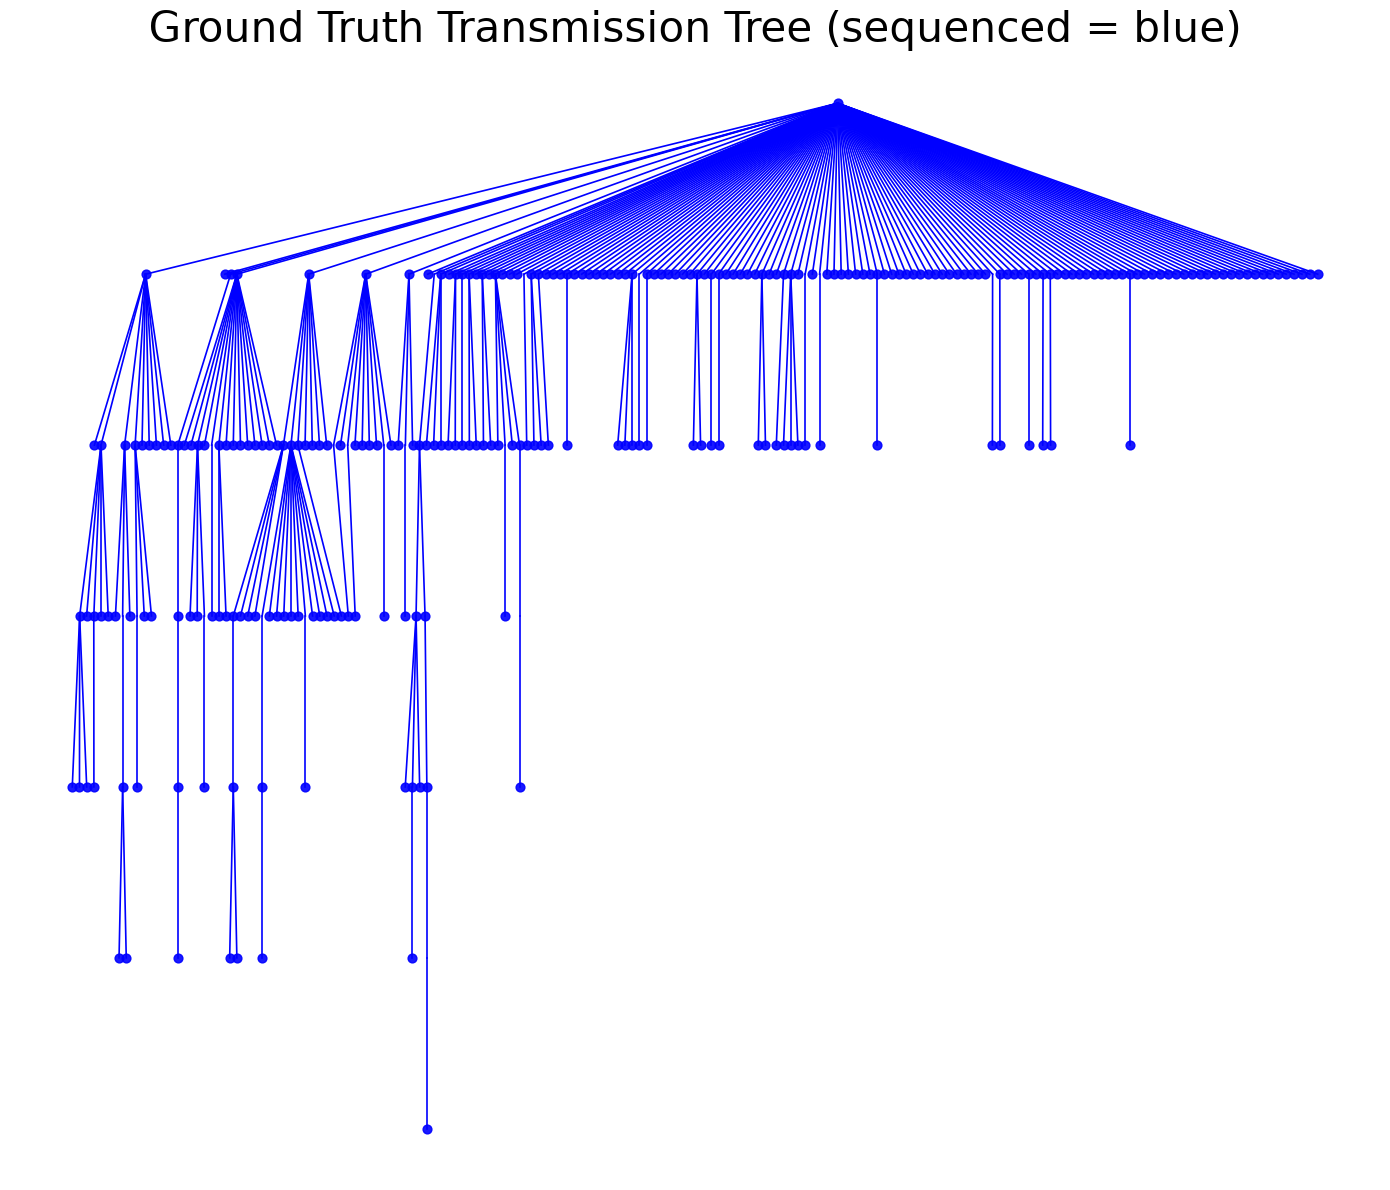

In [ ]:
G_prune = extract_sequenced_subtree(G_infect) # the tree will be pruned to the subtree with every node having at least 1 sequecncing event

plot_erase_mutation_tree(
    G_prune,
    savepath="/home/yutianc/covasim4wastewater/docs/tutorials/results/mutation_tree_policy_seq.png",
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

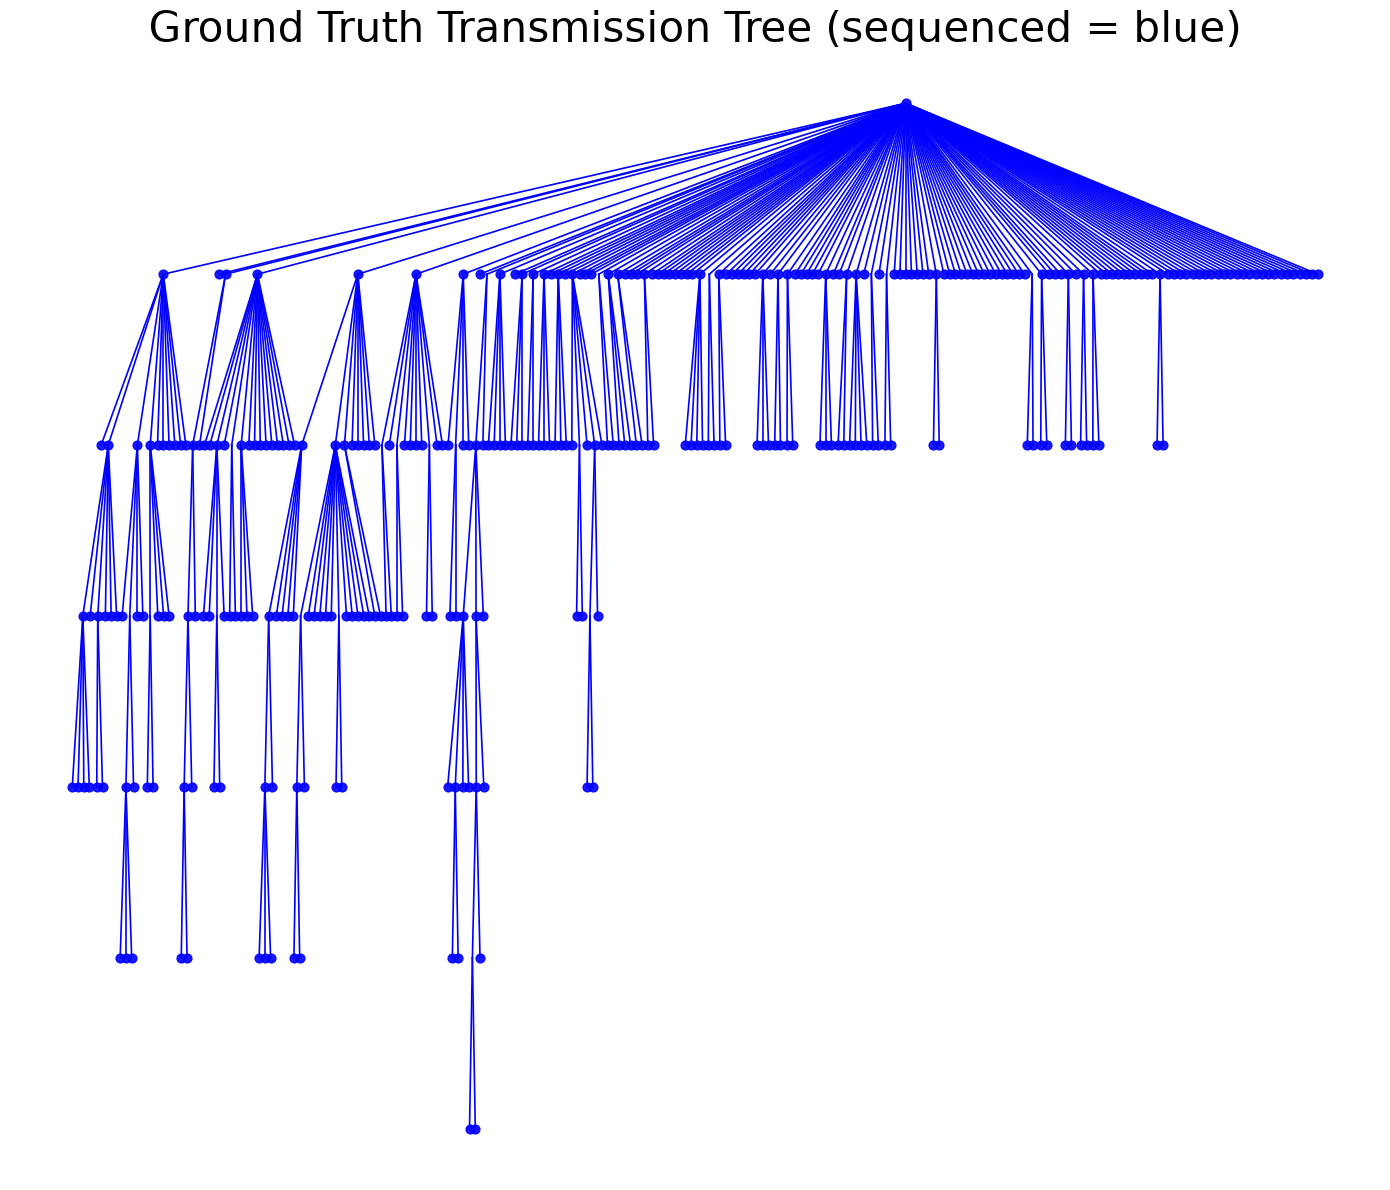

In [113]:
G_prune_leaf = add_internal_leaves(G_prune)
plot_erase_mutation_tree(
    G_prune_leaf,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

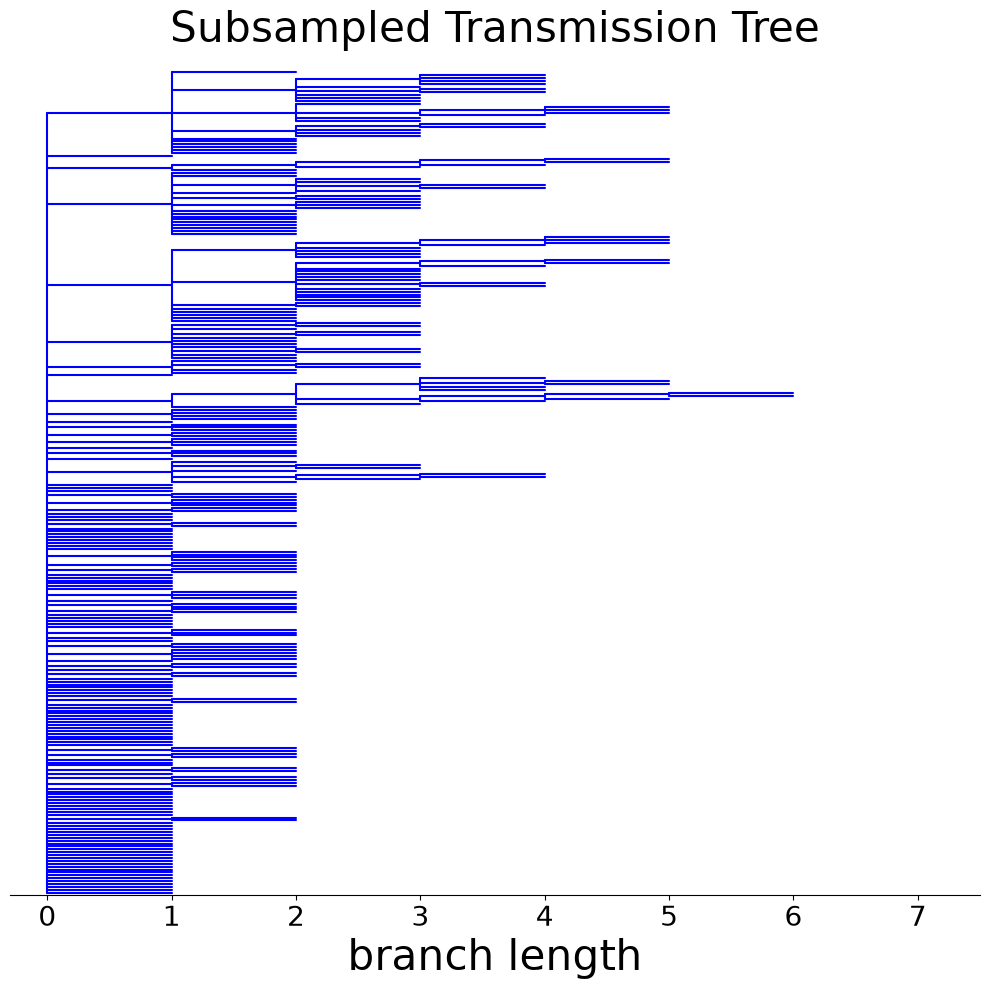

In [114]:
newick_str = mutation_tree_to_newick(G_prune_leaf)

from io import StringIO
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(StringIO(newick_str), "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)    

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

for coll in ax.collections:
    coll.set_color("blue")
    

plt.title("Subsampled Transmission Tree", fontsize=30, pad=20)
plt.tight_layout()

plt.show()

In [115]:
print(f"pop_size (actual agents):     {sim['pop_size']}")
print(f"pop_scale:                    {sim['pop_scale']}")
print(f"scaled_pop_size:              {sim.scaled_pop_size}")
print(f"rescale:                      {sim['rescale']}")

# current scale factor at end of sim
print(f"final scale factor:           {sim.rescale_vec[-1]:.1f}")

pop_size (actual agents):     5000
pop_scale:                    1
scaled_pop_size:              5000
rescale:                      True
final scale factor:           1.0


In [116]:
log    = sim.people.infection_log
n_muts = [e['n_mutations'] for e in log if 'n_mutations' in e]

print(f'Transmission events:    {len(log):,}')
print(f'Mean branch mutations:  {np.mean(n_muts):.3f}')
print(f'Max branch mutations:   {max(n_muts)}')

Transmission events:    7,780
Mean branch mutations:  0.185
Max branch mutations:   4


In [126]:
fasta_path = "/home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test.fasta"
export_fasta_from_G(G_prune, sim, fasta_path)

iqtree_inference = Inference(
    fasta_path=fasta_path,
    prefix="inferred_tree", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()


Running: /home/yutianc/miniforge3/envs/covasim4ww/bin/iqtree -s /home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test.fasta -m JC -asr -redo -pre inferred_tree
IQ-TREE version 3.1.3 for Linux x86 64-bit built Jul 26 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    profchaos.scripps.edu (AVX512, FMA3, 754 GB RAM)
Command: /home/yutianc/miniforge3/envs/covasim4ww/bin/iqtree -s /home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test.fasta -m JC -asr -redo -pre inferred_tree
Seed:    993762 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Fri Sep 25 13:44:21 2026
Kernel:  AVX+FMA - 1 threads (384 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 384 cores!
HINT: -nt AUTO will automatically determine the best number of threads to use.

Readin

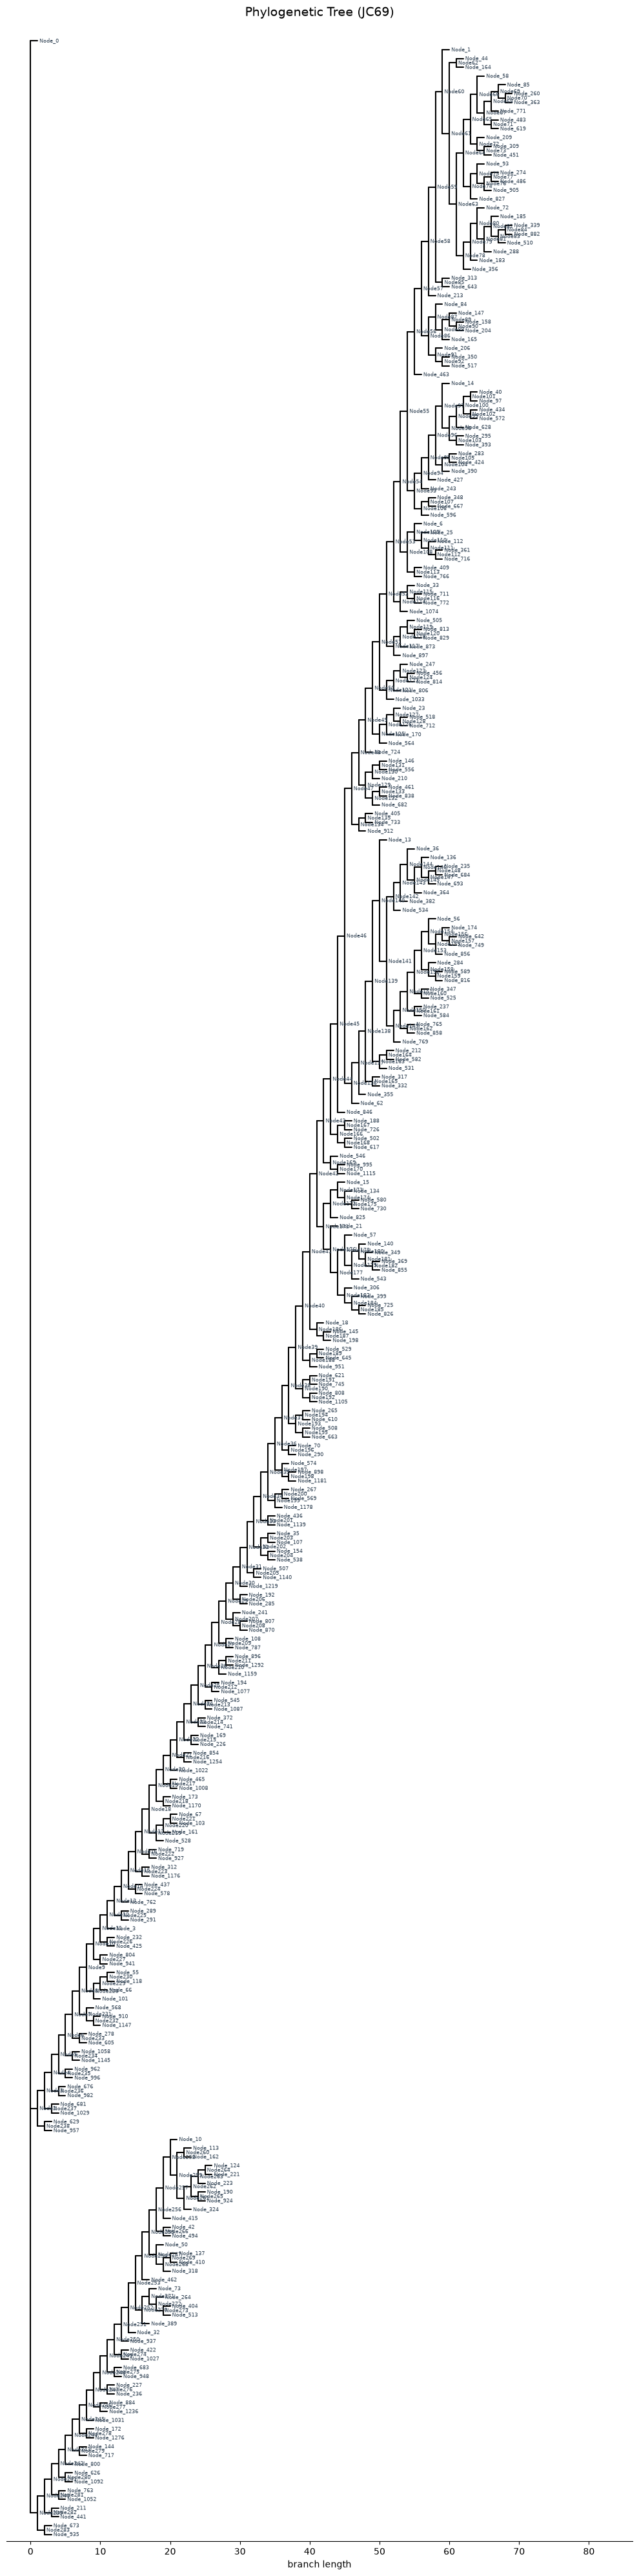

In [128]:
newick_bl1_path = set_all_branch_lengths_to_one("/home/yutianc/covasim4wastewater/docs/tutorials/inferred_tree.treefile")

plot_phylo_tree(newick_bl1_path, savepath=None)

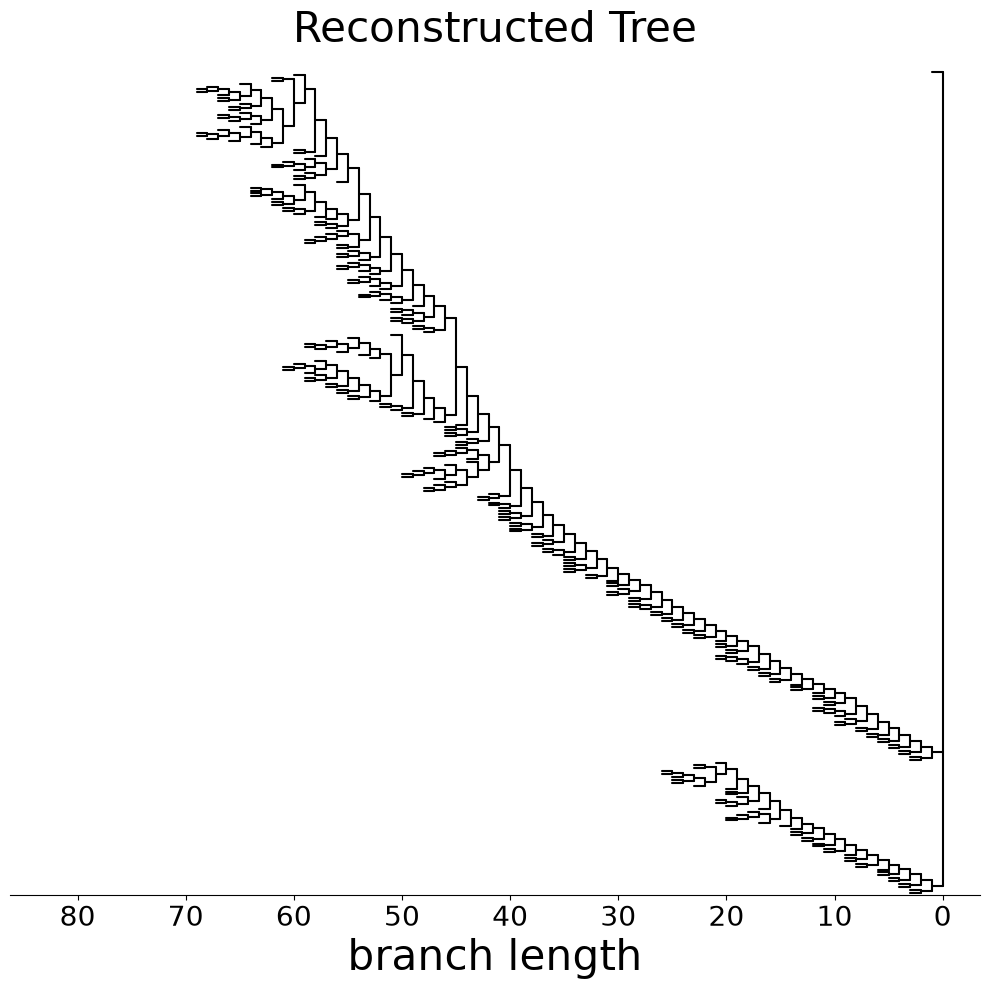

In [129]:
tree = Phylo.read(newick_bl1_path, "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)
ax.invert_xaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

plt.title("Reconstructed Tree", fontsize=30, pad=20)
plt.tight_layout()
plt.show()


In [133]:
from covasim.jhk_covasim4wastewater.intervention_search.cophylogeny.polytomy_tanglegram import run_polytomy_tanglegram

run_polytomy_tanglegram(newick_str, newick_bl1_path)

crossings before: 13414


TooManyChildrenError: This node has 131 children, exceeding the cap of 50. Exactly enumerating 2^131 subsets is not practical.

In [118]:
# cs_routine = sim.get_analyzer('CS_routine')
focus_day = 120
fasta_str = cs_routine.to_fasta(focus_day)
fasta_out = f'./results/clinical_day{focus_day}_0.01.fasta'
with open(fasta_out, 'w') as fh:
    fh.write(fasta_str + '\n')
print(f'Saved clinical FASTA -> {fasta_out}')

Saved clinical FASTA -> ./results/clinical_day120_0.01.fasta


In [ ]:
import pandas as pd

def convert_haplotype_tree_to_long_df(mutation_nodes):
    """
    mutation_nodes: {frozenset of (site, ref, alt) -> node_id}
    Returns long-format df with columns: node, site, ref, alt (numeric).
    """
    rows = []
    for mutation_state, node in mutation_nodes.items():
        if not mutation_state:
            rows.append({"node": node, "site": None, "ref": None, "alt": None})
        for site, ref, alt in mutation_state:
            rows.append({"node": node, "site": int(site), "ref": cv.decode_sequence([ref]), "alt": cv.decode_sequence([alt])})
    return pd.DataFrame(rows)

df_mut_full_tree = convert_haplotype_tree_to_long_df(mutation_nodes)

# drop root node - no  mutation
df_mut_full_tree = df_mut_full_tree.dropna()
df_mut_full_tree["site"] = df_mut_full_tree["site"].astype(int)
df_mut_full_tree["mutation"] = df_mut_full_tree["ref"] + df_mut_full_tree["site"].astype(str) + df_mut_full_tree["alt"]
df_mut_full_tree

,node,site,ref,alt,mutation
1,Node_1,160,A,T,A160T
2,Node_1,18906,G,A,G18906A
3,Node_1,3716,C,G,C3716G
4,Node_1,8962,T,C,T8962C
5,Node_1,494,G,A,G494A
...,...,...,...,...,...
168529,Node_878,3699,T,C,T3699C
168530,Node_878,6353,C,G,C6353G
168531,Node_878,14498,T,A,T14498A
168532,Node_878,43,C,T,C43T


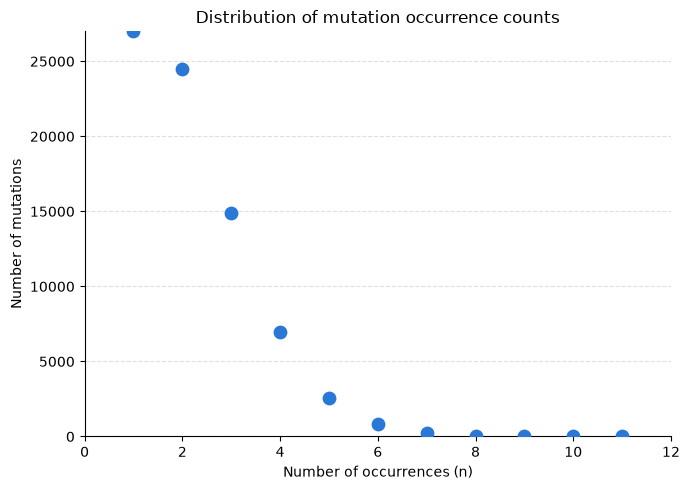

In [ ]:
mutation_counts = df_mut_full_tree["mutation"].value_counts()  # counts per individual mutation
 
n_dist = mutation_counts.value_counts().sort_index()  # index = n, values = number of mutations occurring n times
 
# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(n_dist.index, n_dist.values, color="#2a78d6", s=80, zorder=3)
 
ax.set_xlabel("Number of occurrences (n)")
ax.set_ylabel("Number of mutations")
ax.set_title("Distribution of mutation occurrence counts")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.get_major_locator().set_params(integer=True)
ax.yaxis.get_major_locator().set_params(integer=True)
ax.set_xlim(0, n_dist.index.max() + 1)
ax.set_ylim(0, n_dist.values.max() + 2)
ax.grid(axis="y", linestyle="--", alpha=0.4)
 
plt.tight_layout()
plt.show()
 

In [ ]:
def sanity_check(tree, node_seqs):
    tree_names = {n.name for n in tree.traverse() if n.name}
    state_names = set(node_seqs.keys())
    only_in_tree = tree_names - state_names
    only_in_state = state_names - tree_names
    print(f"Nodes in tree:  {len(tree_names)}")
    print(f"Nodes in state: {len(state_names)}")
    if only_in_tree:
        print(f"  In tree but not .state ({len(only_in_tree)}): {sorted(only_in_tree)[:10]}")
    if only_in_state:
        print(f"  In .state but not tree ({len(only_in_state)}): {sorted(only_in_state)[:10]}")
    if not only_in_tree and not only_in_state:
        print("  All node names match. \u2713")

In [ ]:
from ete3 import Tree
from collections import defaultdict

def load_state_file(state_path):
    node_seqs = defaultdict(dict)
    with open(state_path) as f:
        header = None
        for line in f:
            line = line.rstrip("\n")
            if not line or line.startswith("#"):
                continue
            fields = line.split("\t")
            if header is None:
                header = fields
                continue
            row = dict(zip(header, fields))
            node_seqs[row["Node"]][int(row["Site"])] = row["State"]
    return node_seqs

def load_tip_sequences(fasta_path):
    from Bio import SeqIO
    tip_seqs = {}
    for record in SeqIO.parse(fasta_path, "fasta"):
        tip_seqs[record.id] = {i + 1: base for i, base in enumerate(str(record.seq))}
    return tip_seqs

iqtree = Tree("/home/yutianc/covasim4wastewater/docs/tutorials/sample_0.01.treefile", format=1)
nodes = load_state_file("/home/yutianc/covasim4wastewater/docs/tutorials/sample_0.01.state") # every site for every node
tips = load_tip_sequences("/home/yutianc/covasim4wastewater/docs/tutorials/results/clinical_day120_0.01.fasta")
nodes.update(tips)
sanity_check(iqtree, nodes)

Nodes in tree:  98
Nodes in state: 98
  All node names match. ✓


In [ ]:
def get_mutations(parent_seq, child_seq):
    muts = []
    for site, ref_state in parent_seq.items():
        alt_state = child_seq.get(site)
        if alt_state is not None and alt_state != ref_state:
            muts.append((site, ref_state, alt_state))
    return sorted(muts)

def compute_edge_mutations(tree, node_seqs):
    edge_mutations = {}
    for node in tree.traverse("preorder"): # root to tips
        if node.is_root() or not node.name:
            continue
        parent = node.up
        if parent.name in node_seqs and node.name in node_seqs:
            edge_mutations[node.name] = get_mutations(
                node_seqs[parent.name], node_seqs[node.name] # get the variants
            )
        else:
            edge_mutations[node.name] = []
    return edge_mutations

def compute_cumulative_mutations(tree, edge_mutations):
    cumulative = {}
 
    def recurse(node, parent_cumulative):
        current = frozenset() if node.is_root() else parent_cumulative | set(
            edge_mutations.get(node.name, [])
        )
        if node.name:
            cumulative[node.name] = frozenset(current)
        for child in node.children:
            recurse(child, current)
 
    recurse(tree, frozenset())
    return cumulative

In [ ]:
def convert_sample_tree_to_long_df(mut_dict):
    rows = []
    for node, muts in mut_dict.items():
        if not muts:
            rows.append({"node": node, "site": None, "ref": None, "alt": None})
        for site, ref, alt in muts:
            rows.append({"node": node, "site": int(site), "ref": ref, "alt": alt})

    df = pd.DataFrame(rows)
    return df

In [ ]:
edge_mut = compute_edge_mutations(iqtree, nodes)
cumultative_mut = compute_cumulative_mutations(iqtree, edge_mut)

df_mut_sampled_tree = convert_sample_tree_to_long_df(cumultative_mut)
# drop root node
df_mut_sampled_tree = df_mut_sampled_tree.dropna()
df_mut_sampled_tree["site"] = df_mut_sampled_tree["site"].astype(int)
df_mut_sampled_tree["mutation"] = df_mut_sampled_tree["ref"] + df_mut_sampled_tree["site"].astype(str) + df_mut_sampled_tree["alt"]
df_mut_sampled_tree

,node,site,ref,alt,mutation
1,agent_450,12089,C,A,C12089A
2,agent_450,28986,G,T,G28986T
3,agent_450,8395,T,C,T8395C
4,agent_450,15854,T,A,T15854A
5,agent_450,28295,A,G,A28295G
...,...,...,...,...,...
5668,agent_2918,10720,A,C,A10720C
5669,agent_2918,25382,T,C,T25382C
5670,agent_2918,2570,C,A,C2570A
5671,agent_2918,14672,A,G,A14672G


In [ ]:
full_tree_mut_counts = pd.DataFrame(mutation_counts)
full_tree_mut_counts = full_tree_mut_counts[full_tree_mut_counts["count"] >=6]
len(full_tree_mut_counts[full_tree_mut_counts["count"] >=6])

1157

In [ ]:
# df_mut_full_tree = df_mut_full_tree.drop_duplicates(subset=["site", "ref", "alt"]) # node is the node id in the graph, each represultsultsultsultsultsultsenting a halplotype
df_mut_sampled_tree = df_mut_sampled_tree.drop_duplicates(subset=["mutation"]) # node is the internal node constructed by iqtree inference

common = pd.merge(full_tree_mut_counts, df_mut_sampled_tree, how="inner", on=["mutation"])
common

,mutation,count,node,site,ref,alt
0,A28864T,8,agent_2131,28864,A,T
1,T10667C,8,agent_3340,10667,T,C
2,A26432G,7,agent_3886,26432,A,G
3,A1787C,7,agent_197,1787,A,C
4,T12456A,7,agent_3886,12456,T,A
5,T23307G,6,agent_2812,23307,T,G
6,G13762C,6,agent_2725,13762,G,C
7,A3962G,6,agent_2918,3962,A,G
8,G19846T,6,agent_3404,19846,G,T
9,C9777T,6,agent_208,9777,C,T


In [ ]:
print(len(common)/len(df_mut_full_tree))

8.306978455258021e-05


In [ ]:
# sample rate 5%

cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 250,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

sim = cv.Sim(dict(
    pop_size     = 5_000,
    pop_infected = 1,
        start_day    = '2022-09-01',
        end_day      = '2023-03-31',
    evo_pars = dict(
        enable            = True,
        reference         = REF_FASTA,
        mol_clock_rate    = 1e-6,   # ~1 substitution/genome/month at 30 000 nt
        sub_model         = 'JC', # decides which mutations happen
        fitness_model = "bloom_nt", # controls transmission rate
        fitness_data_path = FITNESS_CSV,
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [cs_routine],
    verbose   = 0,
))
sim.run()

cs_routine = sim.get_analyzer('CS_routine')

focus_day = 180 # this has to be the sample day
cs_batch = cs_routine.samples.get(focus_day, [])

print(f'Day {focus_day} ({sim.date(focus_day)}) — clinical estimate vs true simulation proportions:')
print(f'  {"Variant":12s}  {"Clinical (n=50)":>16}  {"True (sim)":>12}  {"Diff":>8}')
print('  ' + '-' * 56)

for v in variant_names:
    clin_pct = 0.0
    if cs_batch:
        counts = variant_counts(cs_batch)
        clin_pct = counts.get(v, 0) / len(cs_batch)
    true_pct = props[v][focus_day]
    diff     = clin_pct - true_pct
    sign     = '+' if diff >= 0 else ''
    print(f'  {v:12s}  {clin_pct:>16.1%}  {true_pct:>12.1%}  {sign}{diff:>7.1%}')

fasta_str = cs_routine.to_fasta(focus_day)
fasta_out = f'./resultsultsultsultsultsults/clinical_day{focus_day}_0.05.fasta'
with open(fasta_out, 'w') as fh:
    fh.write(fasta_str + '\n')

iqtree_inference = Inference(
    fasta_path=f'./resultsultsultsultsultsults/clinical_day180_0.05.fasta',
    prefix="sample_0.05", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()

total_mut, per_branch_mut = iqtree_inference.count_mutations()
print("n mut in the sampled transmission tree:", total_mut)

In [ ]:
# sample rate 10%
cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 500,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

sim = cv.Sim(dict(
    pop_size     = 5_000,
    pop_infected = 1,
        start_day    = '2022-09-01',
        end_day      = '2023-03-31',
    evo_pars = dict(
        enable            = True,
        reference         = REF_FASTA,
        mol_clock_rate    = 1e-6,   # ~1 substitution/genome/month at 30 000 nt
        sub_model         = 'JC', # decides which mutations happen
        fitness_model = "bloom_nt", # controls transmission rate
        fitness_data_path = FITNESS_CSV,
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [cs_routine],
    verbose   = 0,
))
sim.run()

cs_routine = sim.get_analyzer('CS_routine')

focus_day = 180 # this has to be the sample day
cs_batch = cs_routine.samples.get(focus_day, [])

print(f'Day {focus_day} ({sim.date(focus_day)}) — clinical estimate vs true simulation proportions:')
print(f'  {"Variant":12s}  {"Clinical (n=50)":>16}  {"True (sim)":>12}  {"Diff":>8}')
print('  ' + '-' * 56)

for v in variant_names:
    clin_pct = 0.0
    if cs_batch:
        counts = variant_counts(cs_batch)
        clin_pct = counts.get(v, 0) / len(cs_batch)
    true_pct = props[v][focus_day]
    diff     = clin_pct - true_pct
    sign     = '+' if diff >= 0 else ''
    print(f'  {v:12s}  {clin_pct:>16.1%}  {true_pct:>12.1%}  {sign}{diff:>7.1%}')

fasta_str = cs_routine.to_fasta(focus_day)
fasta_out = f'./resultsultsultsultsultsults/clinical_day{focus_day}_0.1.fasta'
with open(fasta_out, 'w') as fh:
    fh.write(fasta_str + '\n')
print(f'Saved clinical FASTA -> {fasta_out}')
print(f'  ({len(cs_batch)} sequences, {len(fasta_str)} characters)')

iqtree_inference = Inference(
    fasta_path=f'./resultsultsultsultsultsults/clinical_day180_0.1.fasta',
    prefix="sample_0.1", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()

total_mut, per_branch_mut = iqtree_inference.count_mutations()
print("n mut in the sampled transmission tree:", total_mut)

In [ ]:
metrics = Metrics()

pd = metrics.tree_distance("./full_tt.nwk", "./sample_0.01.treefile", metric="faith_pd", alignment_length=29903)
print("rf distance: ", pd)

pd = metrics.tree_distance("./full_tt.nwk", "./sample_0.05.treefile", metric="faith_pd", alignment_length=29903)
print("rf distance: ", pd)

pd = metrics.tree_distance("./full_tt.nwk", "./sample_0.1.treefile", metric="faith_pd", alignment_length=29903)
print("rf distance: ", pd)

In [ ]:
# full transmission tree
full_tt_tree = TransmissionTree(
    tt=sim.make_transtree(),
    ref_seq=list(str(SeqIO.read(REF_FASTA, "fasta").seq)),
)
full_tt_tree.build_tree() 
full_tt_tree.construct_newick()
full_tt_tree.save_newick("./full_tt.nwk")

metrics = Metrics()
n_mut = metrics.count_mutations("./full_tt.nwk")

print("n mut in full transmission tree:", n_mut)